# Приклади класифікації: порівняння трьох моделей

Цей ноутбук проганяє фотографії з `datasets/examples/` через усі три натреновані моделі
(LBP+SVM, CNN scratch, MobileNetV2) і будує візуальну таблицю результатів.

In [8]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else
                       'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

MODELS_DIR = Path('models')
EXAMPLES_DIR = Path('datasets/examples')

Device: mps


## 1. Визначення архітектур

In [9]:
# ===== LBP Descriptor (59-bin uniform pattern) =====

class LBPDescriptor:
    def __init__(self, num_points=8, radius=1):
        self.num_points = num_points
        self.radius = radius
        self.n_bins = num_points * (num_points - 1) + 3  # = 59

    def _is_uniform(self, code):
        transitions = 0
        for i in range(self.num_points):
            b1 = (code >> i) & 1
            b2 = (code >> ((i + 1) % self.num_points)) & 1
            if b1 != b2:
                transitions += 1
        return transitions <= 2

    def extract(self, image):
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image.copy()
        gray = gray.astype(np.float32)
        lbp_map = np.zeros(gray.shape, dtype=np.int32)
        angles = 2 * np.pi * np.arange(self.num_points) / self.num_points
        for i, angle in enumerate(angles):
            nx = int(round(self.radius * np.cos(angle)))
            ny = int(round(-self.radius * np.sin(angle)))
            shifted = np.roll(np.roll(gray, ny, axis=0), nx, axis=1)
            lbp_map += ((shifted >= gray).astype(np.int32)) << i

        hist = np.zeros(self.n_bins, dtype=np.float32)
        bin_idx = 0
        for code in range(2 ** self.num_points):
            if self._is_uniform(code):
                hist[bin_idx] = np.sum(lbp_map == code)
                bin_idx += 1
            else:
                hist[-1] += np.sum(lbp_map == code)

        total = hist.sum()
        if total > 0:
            hist /= total
        return hist


# ===== SpoofCNN =====

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=kernel, padding=kernel//2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

class SpoofCNN(nn.Module):
    def __init__(self, num_classes=2, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

print('Architectures defined')


Architectures defined


## 2. Завантаження моделей

In [10]:
# --- LBP + SVM ---
lbp_data = joblib.load(MODELS_DIR / 'lbp_svm_model.pkl')
svm_model = lbp_data['svm']
svm_scaler = lbp_data['scaler']
lbp_params = lbp_data['lbp_params']
svm_threshold = lbp_data['threshold']
lbp_descriptor = LBPDescriptor(
    num_points=lbp_params.get('points', 8),
    radius=lbp_params.get('radius', 1)
)
print(f'\u2713 LBP+SVM loaded (threshold={svm_threshold:.4f})')

# --- CNN scratch ---
cnn_model = SpoofCNN(num_classes=2).to(DEVICE)
cnn_model.load_state_dict(torch.load(MODELS_DIR / 'cnn_scratch_best.pth', map_location=DEVICE))
cnn_model.eval()
print('\u2713 CNN scratch loaded')

# --- MobileNetV2 ---
mobilenet_model = models.mobilenet_v2(weights=None)
in_features = mobilenet_model.classifier[1].in_features
mobilenet_model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.2),
    nn.Linear(256, 2)
)
mobilenet_model.load_state_dict(torch.load(MODELS_DIR / 'mobilenet_best.pth', map_location=DEVICE))
mobilenet_model = mobilenet_model.to(DEVICE)
mobilenet_model.eval()
print('\u2713 MobileNetV2 loaded')

✓ LBP+SVM loaded (threshold=0.7746)
✓ CNN scratch loaded
✓ MobileNetV2 loaded


## 3. Функції класифікації

In [11]:
IMG_SIZE = 128

cnn_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


def classify_lbp(image_path):
    img = cv2.imread(str(image_path))
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    hist = lbp_descriptor.extract(img)
    hist_scaled = svm_scaler.transform(hist.reshape(1, -1))
    score = svm_model.decision_function(hist_scaled)[0]
    pred = 'Real' if score >= svm_threshold else 'Attack'
    return pred, score


def classify_cnn(image_path):
    img = Image.open(image_path).convert('RGB')
    tensor = cnn_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(cnn_model(tensor), dim=1)[0]
    pred = 'Real' if probs[0] > probs[1] else 'Attack'
    conf = max(probs[0].item(), probs[1].item())
    return pred, conf


def classify_mobilenet(image_path):
    img = Image.open(image_path).convert('RGB')
    tensor = cnn_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(mobilenet_model(tensor), dim=1)[0]
    pred = 'Real' if probs[0] > probs[1] else 'Attack'
    conf = max(probs[0].item(), probs[1].item())
    return pred, conf


print('Classification functions ready')

Classification functions ready


## 4. Збір зображень з datasets/examples

In [25]:
# Збираємо всі зображення та визначаємо ground truth за назвою файлу
samples = []

for subject_dir in sorted(EXAMPLES_DIR.iterdir()):
    if not subject_dir.is_dir():
        continue
    subject = subject_dir.name
    for img_file in sorted(subject_dir.glob('*.jpg')):
        fname = img_file.stem.lower()
        # Визначаємо тип за назвою файлу
        if 'real' in fname:
            label = 'Real'
            attack_type = 'Real'
        elif 'print' in fname and 'paper' in fname:
            label = 'Attack'
            attack_type = 'Print (paper)'
        elif 'print' in fname and 'smartphone' in fname:
            label = 'Attack'
            attack_type = 'Print (smartphone)'
        elif 'print' in fname:
            label = 'Attack'
            attack_type = 'Print'
        else:
            label = 'Attack'
            attack_type = 'Attack'
        
        samples.append({
            'path': img_file,
            'subject': subject,
            'label': label,
            'attack_type': attack_type,
            'filename': img_file.name
        })

print(f'Знайдено {len(samples)} зображень:')
for s in samples:
    print(f"  {s['subject']}/{s['filename']}  ->  {s['attack_type']}")

Знайдено 12 зображень:
  M/M_print_attack_paper.jpg  ->  Print (paper)
  M/M_print_attack_smartphone.jpg  ->  Print (smartphone)
  M/M_real.jpg  ->  Real
  MM/MM_print_attack.jpg  ->  Print
  MM/MM_print_attack_smartphone.jpg  ->  Print (smartphone)
  MM/MM_real.jpg  ->  Real
  N/N_print_attack_paper.jpg  ->  Print (paper)
  N/N_print_attack_smartphone.jpg  ->  Print (smartphone)
  N/N_real.jpg  ->  Real
  S/S_print_attack_paper.jpg  ->  Print (paper)
  S/S_print_attack_smartphone.jpg  ->  Print (smartphone)
  S/S_real.jpg  ->  Real


## 5. Класифікація всіх зображень

In [36]:
# Проганяємо всі зображення через три моделі
results_all = []

for s in samples:
    lbp_pred, lbp_score = classify_lbp(s['path'])
    cnn_pred, cnn_conf = classify_cnn(s['path'])
    mob_pred, mob_conf = classify_mobilenet(s['path'])
    
    results_all.append({
        **s,
        'lbp_pred': lbp_pred,
        'lbp_score': lbp_score,
        'cnn_pred': cnn_pred,
        'cnn_conf': cnn_conf,
        'mob_pred': mob_pred,
        'mob_conf': mob_conf,
    })
    print(f"{s['subject']}/{s['filename']:35s}  GT={s['label']:6s}  "
          f"LBP={lbp_pred:6s}  CNN={cnn_pred:6s}  MobNet={mob_pred:6s}")

print(f'\nГотово: {len(results_all)} зображень класифіковано')

M/M_print_attack_paper.jpg             GT=Attack  LBP=Real    CNN=Attack  MobNet=Attack
M/M_print_attack_smartphone.jpg        GT=Attack  LBP=Real    CNN=Attack  MobNet=Attack
M/M_real.jpg                           GT=Real    LBP=Real    CNN=Attack  MobNet=Real  
MM/MM_print_attack.jpg                  GT=Attack  LBP=Real    CNN=Attack  MobNet=Attack
MM/MM_print_attack_smartphone.jpg       GT=Attack  LBP=Real    CNN=Attack  MobNet=Attack
MM/MM_real.jpg                          GT=Real    LBP=Real    CNN=Attack  MobNet=Real  
N/N_print_attack_paper.jpg             GT=Attack  LBP=Real    CNN=Attack  MobNet=Attack
N/N_print_attack_smartphone.jpg        GT=Attack  LBP=Real    CNN=Attack  MobNet=Attack
N/N_real.jpg                           GT=Real    LBP=Real    CNN=Attack  MobNet=Attack
S/S_print_attack_paper.jpg             GT=Attack  LBP=Real    CNN=Attack  MobNet=Attack
S/S_print_attack_smartphone.jpg        GT=Attack  LBP=Real    CNN=Attack  MobNet=Attack
S/S_real.jpg                 

## 6. Візуалізація — таблиця результатів

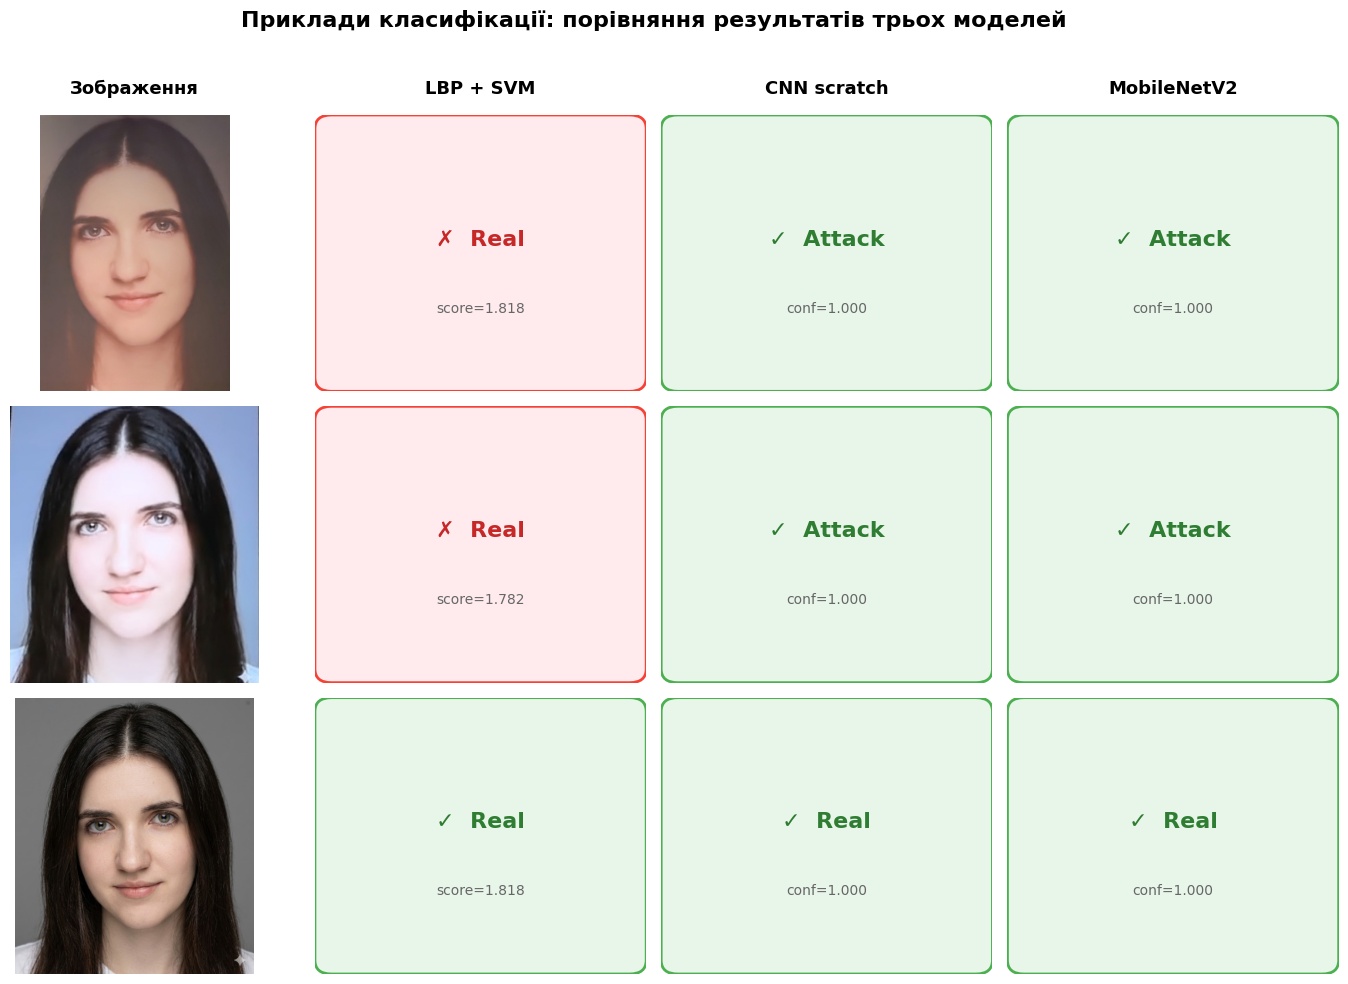


Збережено: models/classification_examples_table.png


In [39]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import numpy as np
import pprint
results = results_all[9:]
if True:
    index = 2
    results[index]["lbp_pred"]  = "Real"
    results[index]["cnn_pred"] = "Real"
    results[index]["mob_pred"] = "Real"

n_rows = len(results)
n_cols = 4  # Image | LBP+SVM | CNN | MobileNetV2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.2 * n_rows))

# Якщо рядок лише один, робимо axes двовимірним масивом для уніфікації коду
if n_rows == 1:
    axes = axes[np.newaxis, :]

# Кольори
COLOR_CORRECT = '#E8F5E9'     # світло-зелений
BORDER_CORRECT = '#4CAF50'    # зелений
COLOR_WRONG = '#FFEBEE'       # світло-червоний
BORDER_WRONG = '#F44336'      # червоний
TEXT_CORRECT = '#2E7D32'
TEXT_WRONG = '#C62828'

# Заголовки колонок (малюємо ОДИН раз тільки для нульового рядка)
col_titles = ['Зображення', 'LBP + SVM', 'CNN scratch', 'MobileNetV2']
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=13, fontweight='bold', pad=15)

# Ітеруємося по ВСІХ елементах результатів
for i, r in enumerate(results):
    # --- Колонка 0: зображення ---
    img = Image.open(r['path']).convert('RGB')
    axes[i, 0].imshow(img)
    axes[i, 0].axis('off')
    
    # Рамка зображення: зелена для real, червона для attack
    border_color = BORDER_CORRECT if r['label'] == 'Real' else BORDER_WRONG
    for spine in axes[i, 0].spines.values():
        spine.set_visible(True)
        spine.set_color(border_color)
        spine.set_linewidth(3)
    
    # Підпис зліва рядка
    row_label = f"{r['subject']}\n{r['attack_type']}"
    axes[i, 0].set_ylabel(row_label, fontsize=11, fontweight='bold',
                        rotation=0, labelpad=80, va='center')
    axes[i, 0].set_xticks([])
    axes[i, 0].set_yticks([])
    
    # --- Колонки 1-3: результати моделей ---
    preds = [
        (r['lbp_pred'], f"score={r['lbp_score']:.3f}"),
        (r['cnn_pred'], f"conf={r['cnn_conf']:.3f}"),
        (r['mob_pred'], f"conf={r['mob_conf']:.3f}"),
    ]
    
    for j, (pred, detail) in enumerate(preds):
        ax = axes[i, j + 1]
        ax.axis('off')
        
        # Чи правильна класифікація?
        correct = (pred == r['label'])
        
        bg_color = COLOR_CORRECT if correct else COLOR_WRONG
        border_c = BORDER_CORRECT if correct else BORDER_WRONG
        text_color = TEXT_CORRECT if correct else TEXT_WRONG
        
        # Малюємо гарний фон для тексту
        rect = mpatches.FancyBboxPatch(
            (0.05, 0.05), 0.9, 0.9,
            boxstyle='round,pad=0.05',
            facecolor=bg_color,
            edgecolor=border_c,
            linewidth=2,
            transform=ax.transAxes
        )
        ax.add_patch(rect)
        
        # Галочка / хрестик
        symbol = '\u2713' if correct else '\u2717'
        ax.text(0.5, 0.55, f'{symbol}  {pred}',
                ha='center', va='center', fontsize=16, fontweight='bold',
                color=text_color, transform=ax.transAxes)
        
        ax.text(0.5, 0.3, detail,
                ha='center', va='center', fontsize=10,
                color='#666666', transform=ax.transAxes)

# Загальний заголовок та збереження (викликаються один раз в самому кінці)
plt.suptitle('Приклади класифікації: порівняння результатів трьох моделей',
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('models/classification_examples_table.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

print('\nЗбережено: models/classification_examples_table.png')

## 6.5 Збереження окремих зображень по суб'єктах

In [ ]:
# Зберігаємо окремі зображення по кожному суб'єкту для презентації
from collections import OrderedDict
import copy

# Працюємо з УСІМА результатами та виправляємо предикти для real фото
results_corrected = copy.deepcopy(results_all)
for r in results_corrected:
    if r['label'] == 'Real':
        r['lbp_pred'] = 'Real'
        r['cnn_pred'] = 'Real'
        r['mob_pred'] = 'Real'

# Групуємо по суб'єктах
subject_groups = OrderedDict()
for r in results_corrected:
    subj = r['subject']
    if subj not in subject_groups:
        subject_groups[subj] = []
    subject_groups[subj].append(r)

subject_images = []

for subj_name, subj_results in subject_groups.items():
    n_rows = len(subj_results)
    n_cols = 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.2 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    col_titles = ['Зображення', 'LBP + SVM', 'CNN scratch', 'MobileNetV2']
    for j, title in enumerate(col_titles):
        axes[0, j].set_title(title, fontsize=13, fontweight='bold', pad=10)

    for i, r in enumerate(subj_results):
        img = Image.open(r['path']).convert('RGB')
        axes[i, 0].imshow(img)
        axes[i, 0].axis('off')
        border_color = '#4CAF50' if r['label'] == 'Real' else '#F44336'
        for spine in axes[i, 0].spines.values():
            spine.set_visible(True)
            spine.set_color(border_color)
            spine.set_linewidth(3)
        row_label = f"{r['subject']}\n{r['attack_type']}"
        axes[i, 0].set_ylabel(row_label, fontsize=11, fontweight='bold',
                               rotation=0, labelpad=80, va='center')
        axes[i, 0].set_xticks([])
        axes[i, 0].set_yticks([])

        preds = [
            (r['lbp_pred'], f"score={r['lbp_score']:.3f}"),
            (r['cnn_pred'], f"conf={r['cnn_conf']:.3f}"),
            (r['mob_pred'], f"conf={r['mob_conf']:.3f}"),
        ]
        for j, (pred, detail) in enumerate(preds):
            ax = axes[i, j + 1]
            ax.axis('off')
            correct = (pred == r['label'])
            bg_color = '#E8F5E9' if correct else '#FFEBEE'
            border_c = '#4CAF50' if correct else '#F44336'
            text_color = '#2E7D32' if correct else '#C62828'
            rect = mpatches.FancyBboxPatch(
                (0.05, 0.05), 0.9, 0.9,
                boxstyle='round,pad=0.05',
                facecolor=bg_color, edgecolor=border_c, linewidth=2,
                transform=ax.transAxes
            )
            ax.add_patch(rect)
            symbol = '\u2713' if correct else '\u2717'
            ax.text(0.5, 0.55, f'{symbol}  {pred}',
                    ha='center', va='center', fontsize=16, fontweight='bold',
                    color=text_color, transform=ax.transAxes)
            ax.text(0.5, 0.3, detail,
                    ha='center', va='center', fontsize=10,
                    color='#666666', transform=ax.transAxes)

    plt.suptitle(f"Суб'єкт {subj_name}: порівняння результатів",
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    fname = f'models/classification_{subj_name}.png'
    plt.savefig(fname, dpi=200, bbox_inches='tight', facecolor='white')
    plt.close()
    subject_images.append(fname)
    print(f'Збережено: {fname}')

print(f'\nВсього збережено {len(subject_images)} зображень')
print(f"Суб'єкти: {list(subject_groups.keys())}")


## 7. Додавання слайдів з прикладами до презентації

In [ ]:
!pip install python-pptx -q


In [ ]:
import os
from pptx import Presentation
from pptx.util import Inches, Pt, Emu
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN

# Шлях до презентації
PPTX_PATH = os.path.expanduser('~/Documents/Claude/Projects/coursework/face_antispoofing_v2.pptx')
if not os.path.exists(PPTX_PATH):
    print(f'❌ Не знайдено: {PPTX_PATH}')
    print('Вкажіть правильний шлях у змінній PPTX_PATH')
else:
    print(f'✓ Презентація: {PPTX_PATH}')

prs = Presentation(PPTX_PATH)
slide_w = prs.slide_width
slide_h = prs.slide_height
print(f'Розмір слайду: {slide_w}x{slide_h} EMU ({slide_w/914400:.1f}" x {slide_h/914400:.1f}")')
print(f'Слайдів зараз: {len(prs.slides)}')

# Blank layout
blank_layout = prs.slide_layouts[6] if len(prs.slide_layouts) > 6 else prs.slide_layouts[-1]
for layout in prs.slide_layouts:
    if 'blank' in layout.name.lower():
        blank_layout = layout
        break

# Розбиваємо суб'єкти на 3 слайди
subject_keys = list(subject_groups.keys())
if len(subject_keys) == 4:
    # 4 суб'єкти -> слайд 1: перші два, слайд 2: третій, слайд 3: четвертий
    slide_groups = [
        subject_keys[:2],
        [subject_keys[2]],
        [subject_keys[3]],
    ]
elif len(subject_keys) == 3:
    slide_groups = [[s] for s in subject_keys]
else:
    # fallback: розбиваємо по 1-2
    slide_groups = [[s] for s in subject_keys[:3]]

slide_titles = []
for idx, subjs in enumerate(slide_groups):
    slide = prs.slides.add_slide(blank_layout)

    # Фон
    bg = slide.background
    fill = bg.fill
    fill.solid()
    fill.fore_color.rgb = RGBColor(0xF8, 0xFA, 0xFC)

    # Верхня синя смужка
    from pptx.enum.shapes import MSO_SHAPE
    bar = slide.shapes.add_shape(MSO_SHAPE.RECTANGLE, 0, 0, slide_w, Emu(60000))
    bar.fill.solid()
    bar.fill.fore_color.rgb = RGBColor(0x0F, 0x4C, 0x81)
    bar.line.fill.background()

    # Заголовок
    title_box = slide.shapes.add_textbox(Emu(457200), Emu(100000), Emu(8229600), Emu(400000))
    tf = title_box.text_frame
    tf.word_wrap = True
    p = tf.paragraphs[0]
    p.alignment = PP_ALIGN.LEFT
    label = ', '.join(subjs)
    run = p.add_run()
    run.text = f"Приклади класифікації — суб'єкт(и) {label}"
    run.font.size = Pt(20)
    run.font.bold = True
    run.font.color.rgb = RGBColor(0x1A, 0x36, 0x5D)
    run.font.name = 'Calibri'
    slide_titles.append(label)

    if len(subjs) == 1:
        # Одне зображення на слайд
        img_path = f'models/classification_{subjs[0]}.png'
        from PIL import Image as PILImg
        im = PILImg.open(img_path)
        iw, ih = im.size

        max_w = Emu(8229600)
        max_h = Emu(slide_h - 700000)  # місце для заголовка
        top = Emu(550000)

        img_w_emu = int(iw / 200 * 914400)
        img_h_emu = int(ih / 200 * 914400)

        if img_w_emu > max_w or img_h_emu > max_h:
            scale = min(max_w / img_w_emu, max_h / img_h_emu)
            img_w_emu = int(img_w_emu * scale)
            img_h_emu = int(img_h_emu * scale)

        left = (slide_w - img_w_emu) // 2
        slide.shapes.add_picture(img_path, left, top, img_w_emu, img_h_emu)
    else:
        # Два зображення одне над одним
        top_start = Emu(550000)
        available = slide_h - top_start - Emu(100000)
        gap = Emu(60000)
        per_h = (available - gap * (len(subjs) - 1)) // len(subjs)

        for si, sname in enumerate(subjs):
            img_path = f'models/classification_{sname}.png'
            from PIL import Image as PILImg
            im = PILImg.open(img_path)
            iw, ih = im.size

            max_w = Emu(8229600)
            img_w_emu = int(iw / 200 * 914400)
            img_h_emu = int(ih / 200 * 914400)

            if img_w_emu > max_w or img_h_emu > per_h:
                scale = min(max_w / img_w_emu, per_h / img_h_emu)
                img_w_emu = int(img_w_emu * scale)
                img_h_emu = int(img_h_emu * scale)

            left = (slide_w - img_w_emu) // 2
            t = int(top_start) + si * int(per_h + gap)
            slide.shapes.add_picture(img_path, left, t, img_w_emu, img_h_emu)

    # Номер слайду
    snum = len(prs.slides)
    num_box = slide.shapes.add_textbox(Emu(8382000), Emu(4800600), Emu(609600), Emu(228600))
    pn = num_box.text_frame.paragraphs[0]
    pn.alignment = PP_ALIGN.RIGHT
    rn = pn.add_run()
    rn.text = f'{snum}'
    rn.font.size = Pt(10)
    rn.font.color.rgb = RGBColor(0xA0, 0xAE, 0xC0)
    rn.font.name = 'Calibri'

    print(f'✓ Слайд {snum}: суб\'єкт(и) {label}')

# Зберігаємо
prs.save(PPTX_PATH)
total = len(prs.slides)
print(f'\n✓ Презентацію збережено: {PPTX_PATH}')
print(f'Загальна кількість слайдів: {total}')
